# Source Separation Decomposition

Visualises the encoder–decoder decomposition from Phase 1 pretraining (`03b_source_sep_pretraining.py`).

For each of the 7 label combinations (single-, dual-, and triple-positive wells), N random examples are shown.  Each example row has:
- **Col 0** — raw input curve (black) + sum of active decoded channels (red dashed) + individual decoded channels (thin coloured lines).
- **Cols 1–3** — decoded curve for each target channel (solid) overlaid on real single-target reference curves (faint) and their mean (dotted).  Absent channels are shown at reduced opacity so suppression is visible.

## Parameters (Config cell)

| Variable | Values | Effect |
|---|---|---|
| `SUPCON_LEVEL` | `0` / `1` / `2` / `3` | **0** = Family A — standard Phase 1 encoder (no SC loss). **1–3** = Family B — SC-specific precon encoder; selects `source_sep_precon_sc{N}_encoder_weights.weights.h5`. |
| `USE_CRF` | `False` / `True` | Sigmoid vs CRF-MRF classification head. Does not change encoder/decoder weights — used only to display the corresponding Phase 2+3 model key. |

> **Prerequisite**: run `03b_source_sep_pretraining.py` for the chosen SC level — encoder and decoder weights must exist. The derivation cell prints the exact command if they are missing.

In [1]:
import sys
from pathlib import Path
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import joblib

_MULTIPLEX = Path('..').resolve()
sys.path.insert(0, str(_MULTIPLEX))
sys.path.insert(0, str(_MULTIPLEX / 'utils' / 'model_training'))

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import config_multiplex as config
from model_utils_source_sep import build_source_sep_encoder, build_parametric_decoder


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## Config

In [72]:
# ── Experiment ────────────────────────────────────────────────────────
EXP_PATH = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex/02_ACA_qdPCR_balanced')
# EXP_PATH = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex/01_ACA_qdPCR')

# ── Model variant ─────────────────────────────────────────────────────
# SUPCON_LEVEL  0   = Family A — standard Phase 1 encoder (no SC loss, λ_supcon=0)
#               1/2/3 = Family B — SC-specific precon encoder (Jaccard SupCon during Phase 1)
# USE_CRF       False = sigmoid BCE head, True = CRF-MRF head
#               (only affects Phase 2+3 model key displayed below;
#                the Phase 1 encoder & decoder weights are the same either way)
SUPCON_LEVEL = 0      # 0 | 1 | 2 | 3
USE_CRF      = False  # False | True

# ── Architecture (must match 03b --d_shared / --d_target) ─────────────
D_SHARED = 16
D_TARGET = 10

# ── Visualisation ─────────────────────────────────────────────────────
N_EXAMPLES   = 5    # random wells shown per label combination
N_REF_CURVES = 20   # single-target reference curves overlaid per channel
SEED         = 42

In [73]:
# ── Derive encoder weight path and Phase 2+3 model key ────────────────
assert SUPCON_LEVEL in (0, 1, 2, 3), "SUPCON_LEVEL must be 0, 1, 2, or 3"

if SUPCON_LEVEL == 0:
    enc_path = EXP_PATH / 'source_sep_encoder_weights.weights.h5'
else:
    enc_path = EXP_PATH / f'source_sep_precon_sc{SUPCON_LEVEL}_encoder_weights.weights.h5'

dec_paths = [EXP_PATH / f'source_sep_decoder_{j}_weights.weights.h5'
             for j in range(3)]  # updated once n_targets is known

# Phase 2+3 key for reference (same naming convention as ML_FACTORIES)
_precon  = SUPCON_LEVEL > 0
_base    = 'cnn_gru_source_sep' + ('_precon' if _precon else '')
_sc_sfx  = ['', '_supcon', '_supcon2', '_supcon3'][SUPCON_LEVEL]
_crf_sfx = '_crf' if USE_CRF else ''
MODEL_KEY_P3 = f'{_base}{_crf_sfx}{_sc_sfx}_p3'
MODEL_KEY_P2 = f'{_base}{_crf_sfx}{_sc_sfx}_p2'

family_label = 'A (standard)' if SUPCON_LEVEL == 0 else f'B (precon SC{SUPCON_LEVEL})'
print(f'Family {family_label}  |  {"CRF-MRF" if USE_CRF else "Sigmoid"}')
print(f'  Encoder weights : {enc_path.name}')
print(f'  Phase 2+3 key   : {MODEL_KEY_P3}')
print(f'                    {MODEL_KEY_P2}  (p2 — frozen encoder only)')
if not enc_path.exists():
    print(f'\n  [!] Encoder weights not found. Run:')
    if SUPCON_LEVEL == 0:
        print(f'      python 03b_source_sep_pretraining.py --force_rerun --validate')
    else:
        print(f'      python 03b_source_sep_pretraining.py --precon --supcon {SUPCON_LEVEL} --force_rerun --validate')

Family A (standard)  |  Sigmoid
  Encoder weights : source_sep_encoder_weights.weights.h5
  Phase 2+3 key   : cnn_gru_source_sep_p3
                    cnn_gru_source_sep_p2  (p2 — frozen encoder only)


## Load data

In [74]:
data_path    = EXP_PATH / config.TRAINING_DATA_PATH
data         = joblib.load(data_path)

X_curves     = data['curves']['ori_curves'].astype(np.float32)   # (N, T)
y_binary     = data['label_binarized'].astype(np.int32)          # (N, 3)
all_targets  = data['all_targets']
T            = X_curves.shape[1]
N, n_targets = y_binary.shape

print(f'N={N}, T={T}, targets={all_targets}')
print()
combos, counts = np.unique(y_binary, axis=0, return_counts=True)
for c, n in zip(combos, counts):
    names = '+'.join(all_targets[j] for j in range(n_targets) if c[j])
    print(f'  {names or "Negative":20s}  n={n:,}')

N=10383, T=45, targets=['KPC', 'NDM', 'VIM']

  VIM                   n=1,541
  NDM                   n=1,643
  NDM+VIM               n=1,535
  KPC                   n=875
  KPC+VIM               n=1,582
  KPC+NDM               n=1,638
  KPC+NDM+VIM           n=1,569


## Load model

In [75]:
dec_paths = [EXP_PATH / f'source_sep_decoder_{j}_weights.weights.h5'
             for j in range(n_targets)]

missing = [p for p in [enc_path] + dec_paths if not p.exists()]
if missing:
    cmd = ('python 03b_source_sep_pretraining.py --force_rerun --validate'
           if SUPCON_LEVEL == 0 else
           f'python 03b_source_sep_pretraining.py --precon --supcon {SUPCON_LEVEL} --force_rerun --validate')
    raise FileNotFoundError(
        'Missing weight files:\n'
        + '\n'.join(f'  {p}' for p in missing)
        + f'\n\nRun: {cmd}'
    )

tf.keras.backend.clear_session()
encoder  = build_source_sep_encoder(T, D_SHARED, D_TARGET, n_targets)
decoders = [build_parametric_decoder(D_SHARED, D_TARGET, T_max=T, j=j)
            for j in range(n_targets)]
encoder.load_weights(enc_path)
for j, dec in enumerate(decoders):
    dec.load_weights(dec_paths[j])

print(f'Loaded: {enc_path.name}')
print(f'Encoder  params: {encoder.count_params():,}')
for j, dec in enumerate(decoders):
    print(f'Decoder {all_targets[j]:3s} params: {dec.count_params():,}')

Loaded: source_sep_encoder_weights.weights.h5
Encoder  params: 50,814
Decoder KPC params: 4,101
Decoder NDM params: 4,101
Decoder VIM params: 4,101


## Decode all curves

In [76]:
def render_sigmoid_np(params):
    T_ = X_curves.shape[1]
    Fm = params[:, 0:1]; Fb = params[:, 1:2]
    Sc = params[:, 2:3]; Cs = params[:, 3:4]; As = params[:, 4:5]
    t  = np.arange(T_, dtype=np.float32)[np.newaxis, :]
    return Fm / (1.0 + np.exp(-Sc * (t - Cs))) ** As + Fb

X_enc    = np.expand_dims(X_curves, -1)                          # (N, T, 1)
Z        = encoder.predict(X_enc, batch_size=512, verbose=1)     # (N, d_sh+n*d_t)

z_shared = Z[:, :D_SHARED]
z_parts  = [Z[:, D_SHARED + j*D_TARGET : D_SHARED + (j+1)*D_TARGET]
            for j in range(n_targets)]

dec_curves = []
for j, dec in enumerate(decoders):
    dec_in   = np.concatenate([z_shared, z_parts[j]], axis=-1).astype(np.float32)
    params_j = dec.predict(dec_in, batch_size=512, verbose=0)    # (N, 5)
    dec_curves.append(render_sigmoid_np(params_j))               # (N, T)

# Active-channel reconstruction per well
recon = sum(y_binary[:, j:j+1] * dec_curves[j] for j in range(n_targets))
mse   = np.mean((X_curves - recon) ** 2, axis=1)
print(f'\nReconstruction MSE  mean={mse.mean():.5f}  '
      f'median={np.median(mse):.5f}  p95={np.percentile(mse, 95):.5f}')

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Reconstruction MSE  mean=0.01931  median=0.01239  p95=0.05686


## Reference curve banks (single-target wells)

In [77]:
rng       = np.random.default_rng(SEED)
ref_banks = []
for j, tgt in enumerate(all_targets):
    mask_j = (y_binary.sum(axis=1) == 1) & (y_binary[:, j] == 1)
    bank_j = X_curves[mask_j]
    idx    = rng.choice(len(bank_j), size=min(N_REF_CURVES, len(bank_j)), replace=False)
    ref_banks.append(bank_j[idx])
    print(f'  {tgt}: {mask_j.sum():,} single-target wells, showing {len(idx)}')

  KPC: 875 single-target wells, showing 20
  NDM: 1,643 single-target wells, showing 20
  VIM: 1,541 single-target wells, showing 20


## Visualisation

In [78]:
COLORS = {t: c for t, c in zip(all_targets, ['#4472C4', '#ED7D31', '#70AD47'])}
t_axis = np.arange(T)


def plot_combo(combo, n_examples=N_EXAMPLES, seed=SEED):
    combo = np.asarray(combo, dtype=np.int32)
    mask  = np.all(y_binary == combo, axis=1)
    idxs  = np.where(mask)[0]
    if len(idxs) == 0:
        print(f'No wells with combo {combo.tolist()}'); return
    rng2 = np.random.default_rng(seed)
    pick = rng2.choice(idxs, size=min(n_examples, len(idxs)), replace=False)

    active = [j for j in range(n_targets) if combo[j]]
    label  = '+'.join(all_targets[j] for j in active) or 'Negative'

    nrows = len(pick)
    ncols = n_targets + 1
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.5 * ncols, 2.8 * nrows), squeeze=False)
    fig.suptitle(f'{label}  ({len(idxs):,} wells total, showing {nrows})',
                 fontsize=12, fontweight='bold', y=1.01)

    # Column titles
    axes[0, 0].set_title('Original + active sum', fontsize=9)
    for j, tgt in enumerate(all_targets):
        suffix = '' if combo[j] else ' (absent)'
        col    = COLORS[tgt] if combo[j] else 'grey'
        axes[0, j + 1].set_title(f'{tgt}{suffix}', fontsize=9, color=col)

    for row, wi in enumerate(pick):
        # ── Col 0: original + decomposition ───────────────────────
        ax0 = axes[row, 0]
        ax0.plot(t_axis, X_curves[wi], color='black', lw=1.5, label='Original', zorder=5)
        ax0.plot(t_axis, recon[wi],    color='#C00000', lw=1.2, ls='--',
                 label='Active sum', zorder=4)
        for j in range(n_targets):
            ax0.plot(t_axis, dec_curves[j][wi],
                     color=COLORS[all_targets[j]], lw=0.8,
                     alpha=0.75 if combo[j] else 0.25, zorder=3)
        ax0.set_ylabel(f'well {wi}', fontsize=7)
        if row == 0:
            ax0.legend(fontsize=6, loc='upper left', framealpha=0.7)
        ax0.tick_params(labelsize=7)
        ax0.set_xticks(np.arange(0, T, 10))

        # ── Cols 1+: decoded channel j ────────────────────────────
        for j, tgt in enumerate(all_targets):
            ax  = axes[row, j + 1]
            col = COLORS[tgt]
            is_active = bool(combo[j])
            # Reference curves
            for rc in ref_banks[j]:
                ax.plot(t_axis, rc, color=col, lw=0.4, alpha=0.12, zorder=1)
            ax.plot(t_axis, ref_banks[j].mean(axis=0), color=col, lw=1.0,
                    ls=':', alpha=0.55, label='Ref mean', zorder=2)
            # Decoded
            ax.plot(t_axis, dec_curves[j][wi], color=col,
                    lw=1.5 if is_active else 0.8,
                    alpha=1.0 if is_active else 0.4,
                    label='Decoded', zorder=3)
            if row == 0:
                ax.legend(fontsize=6, loc='upper left', framealpha=0.7)
            ax.tick_params(labelsize=7)
            ax.set_xticks(np.arange(0, T, 10))

    for ax in axes[-1]:
        ax.set_xlabel('Cycle', fontsize=8)

    plt.tight_layout()
    plt.show()

print('plot_combo() ready')

plot_combo() ready


### KPC only

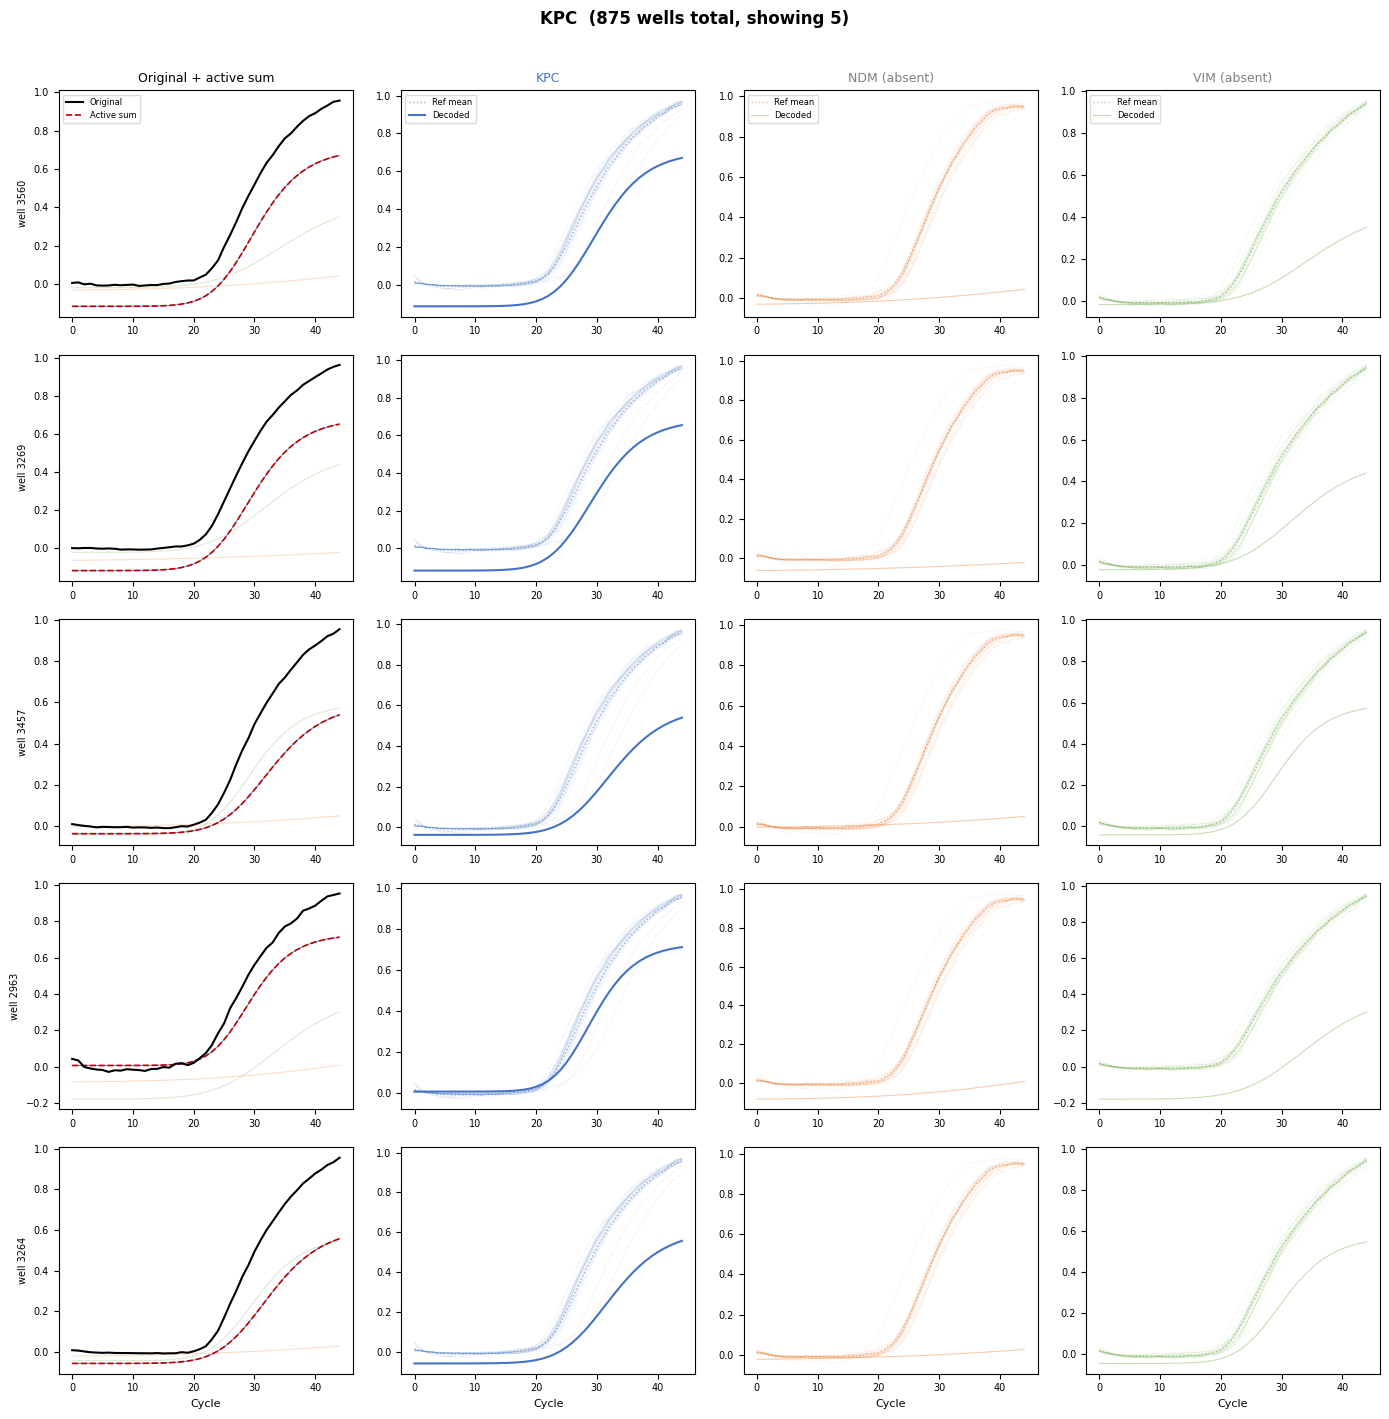

In [79]:
plot_combo([1, 0, 0])

### NDM only

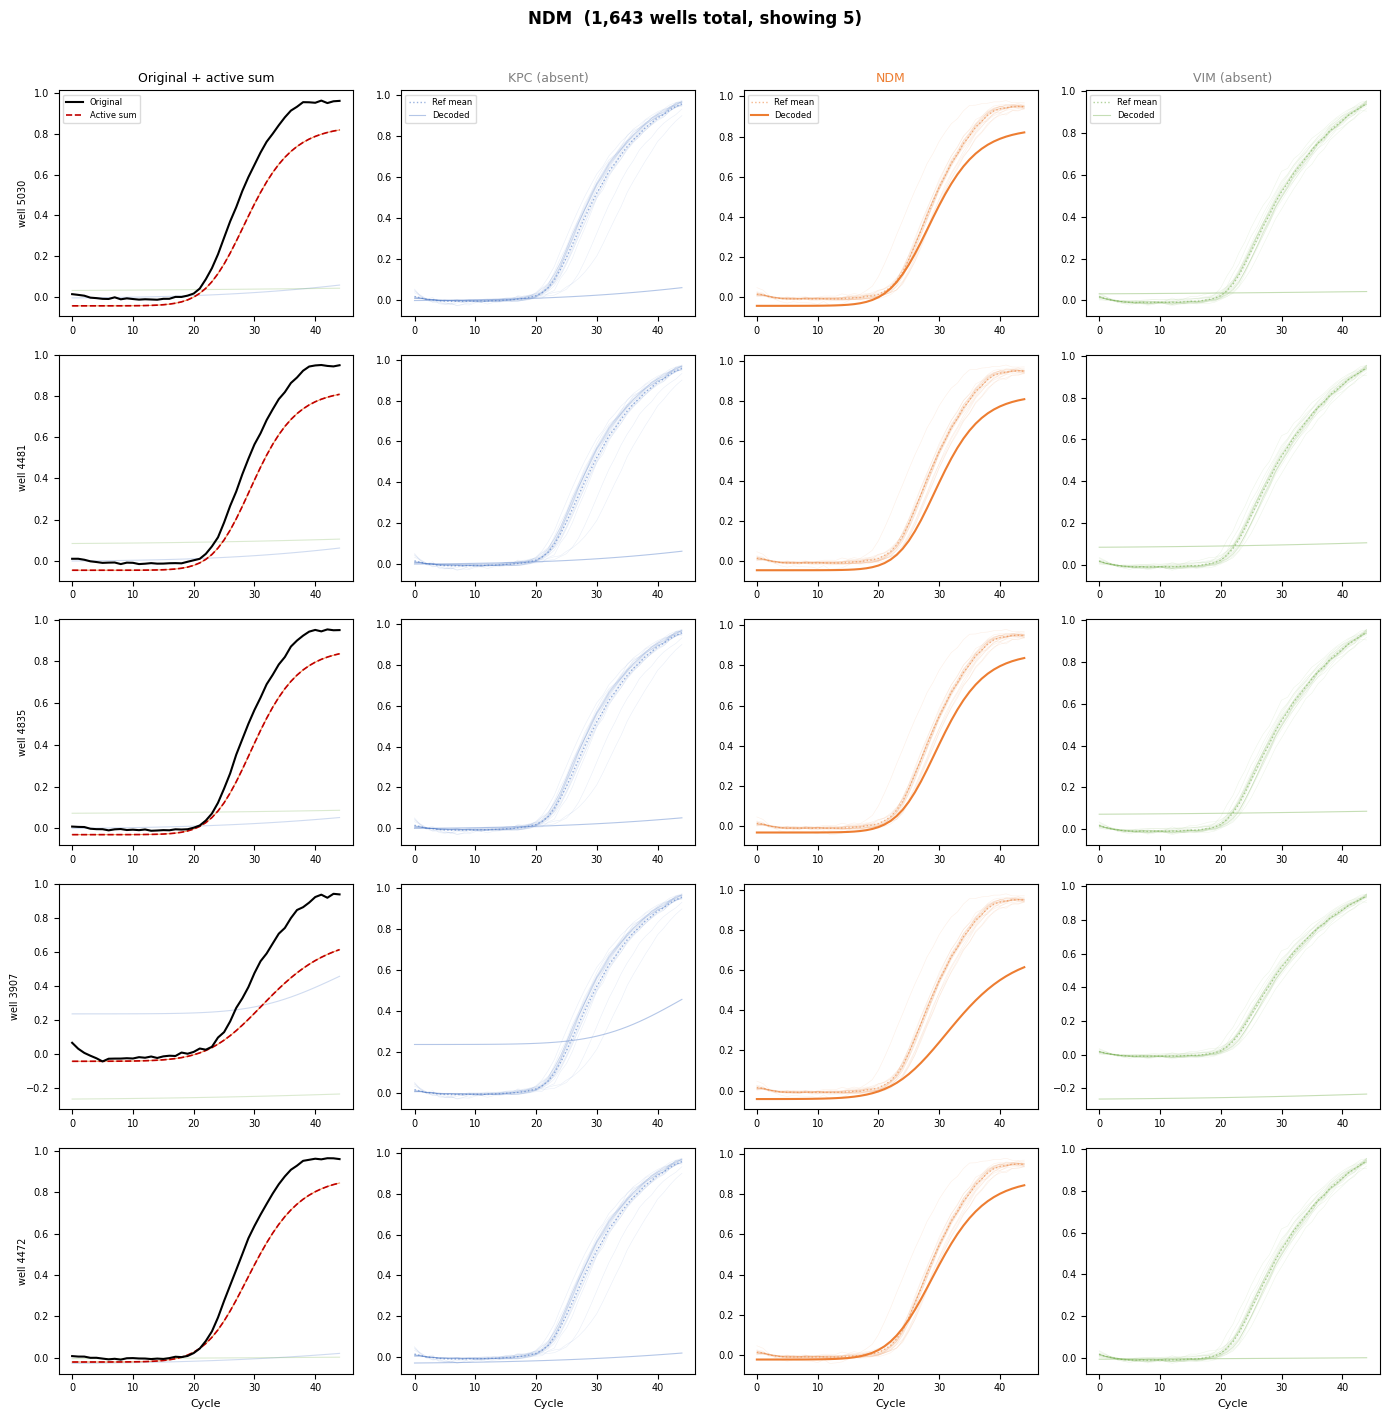

In [80]:
plot_combo([0, 1, 0])

### VIM only

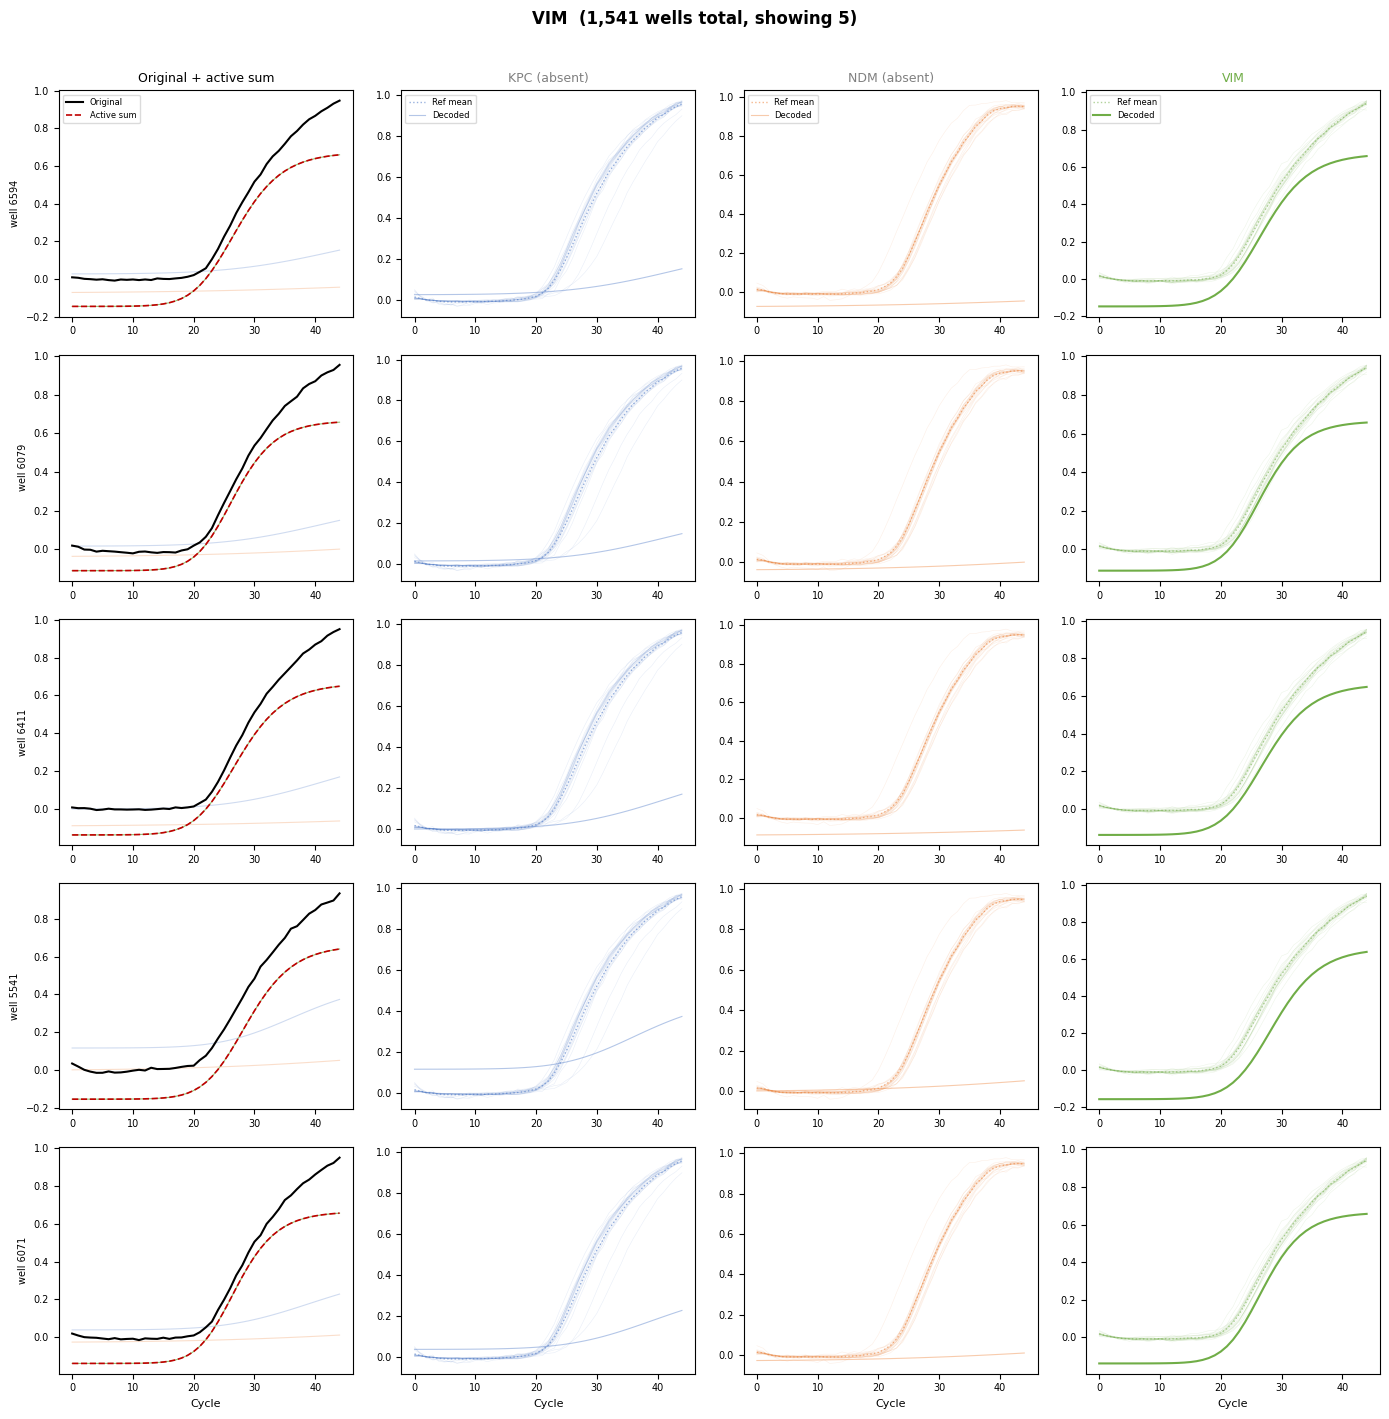

In [81]:
plot_combo([0, 0, 1])

### KPC + NDM

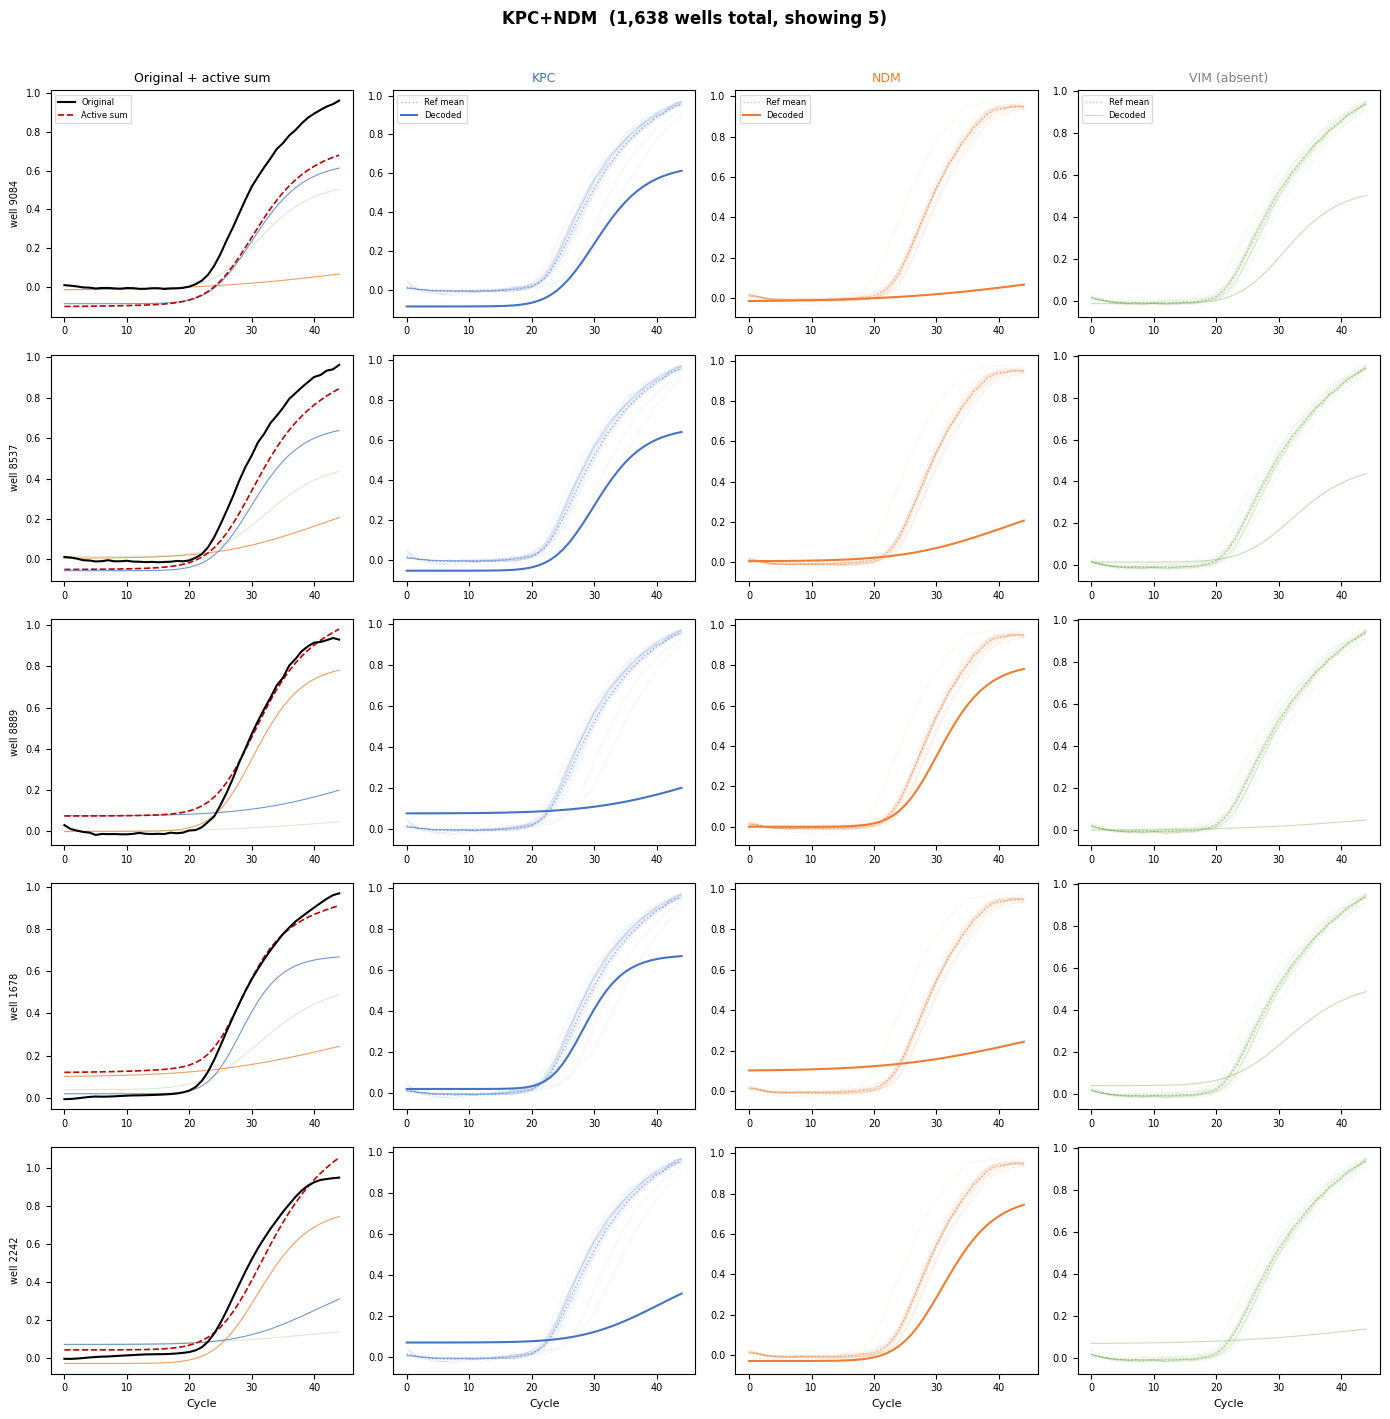

In [82]:
plot_combo([1, 1, 0])

### KPC + VIM

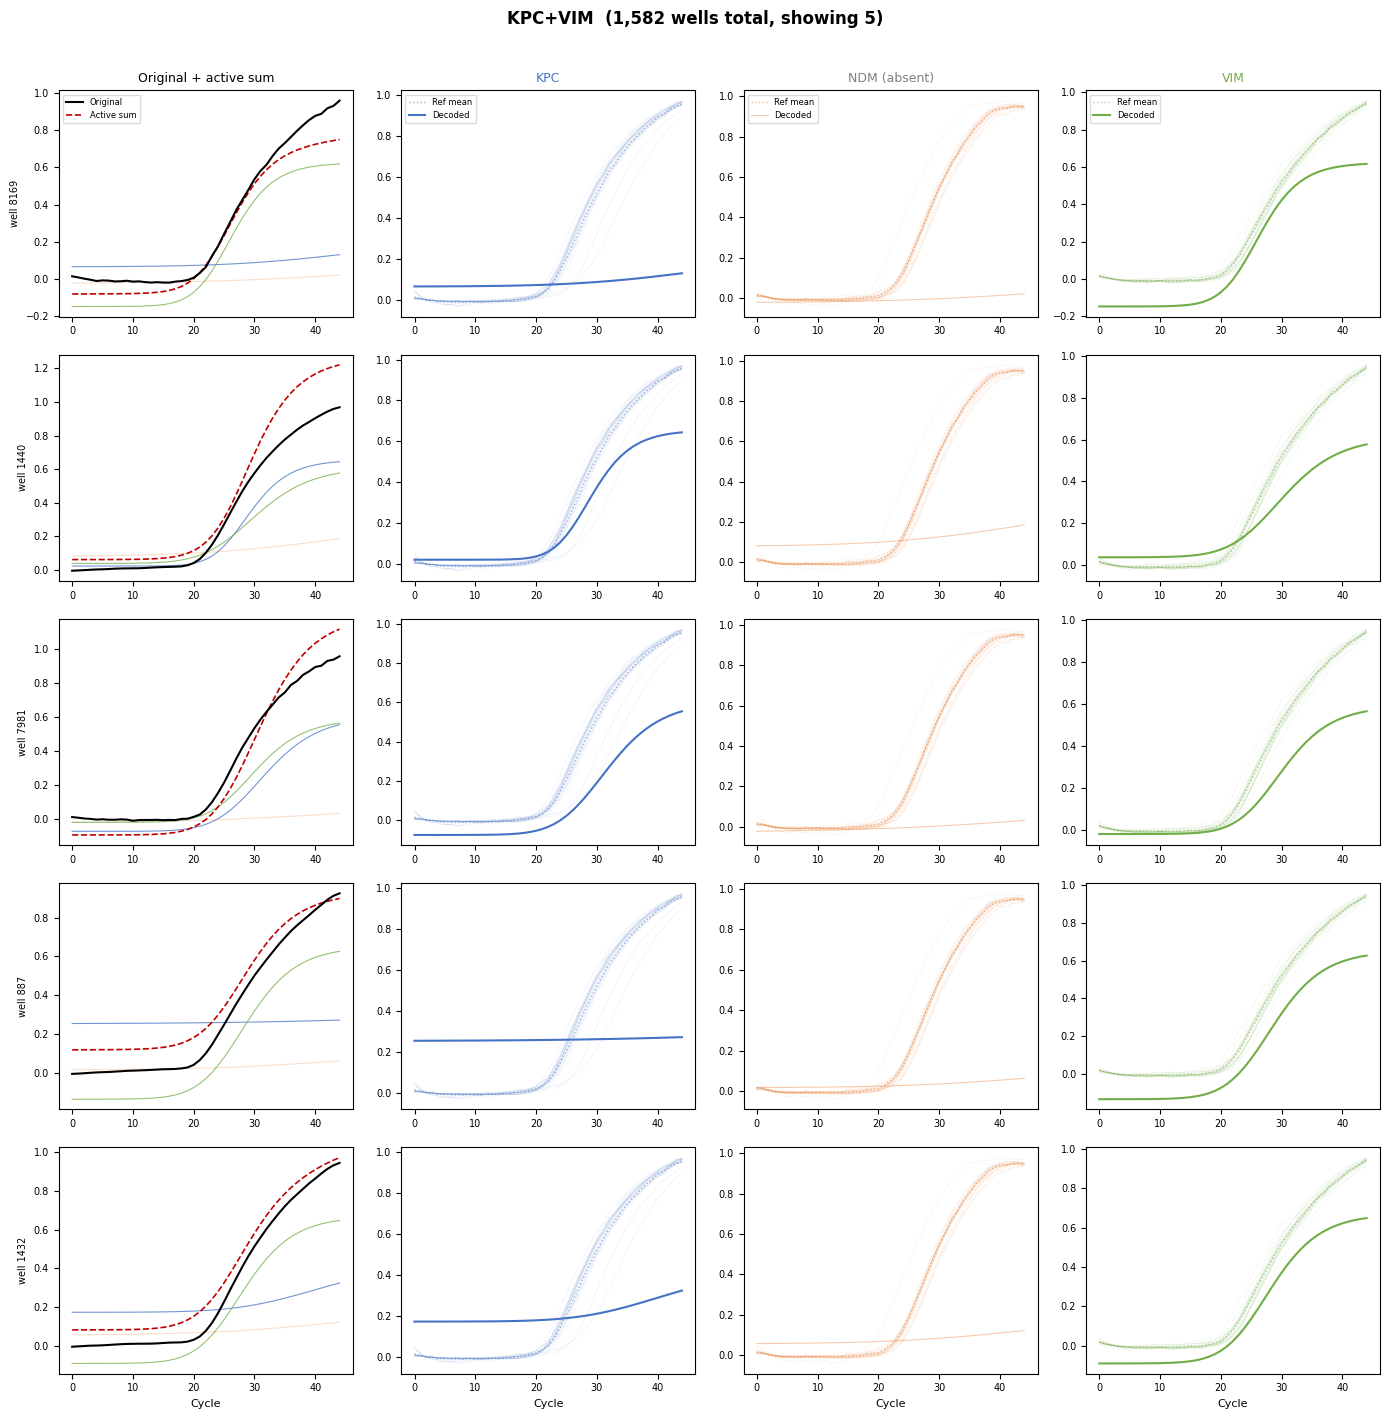

In [83]:
plot_combo([1, 0, 1])

### NDM + VIM

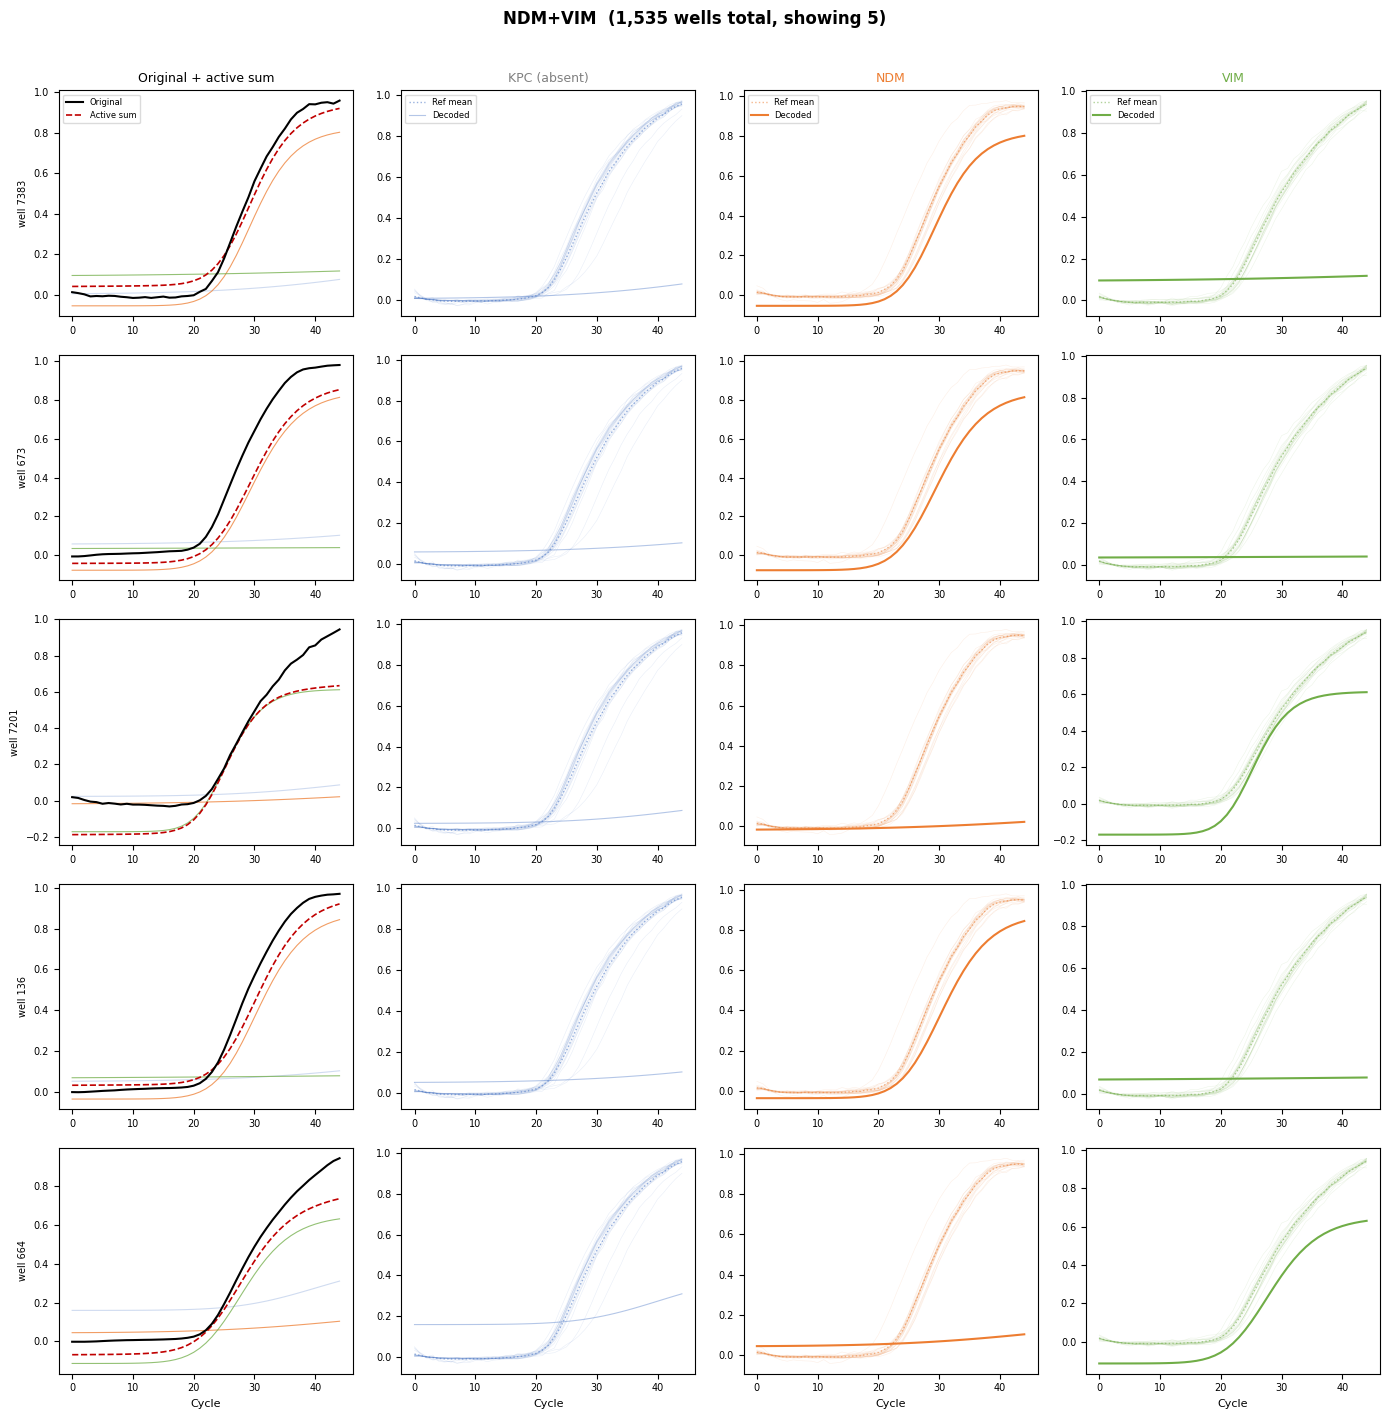

In [84]:
plot_combo([0, 1, 1])

### KPC + NDM + VIM

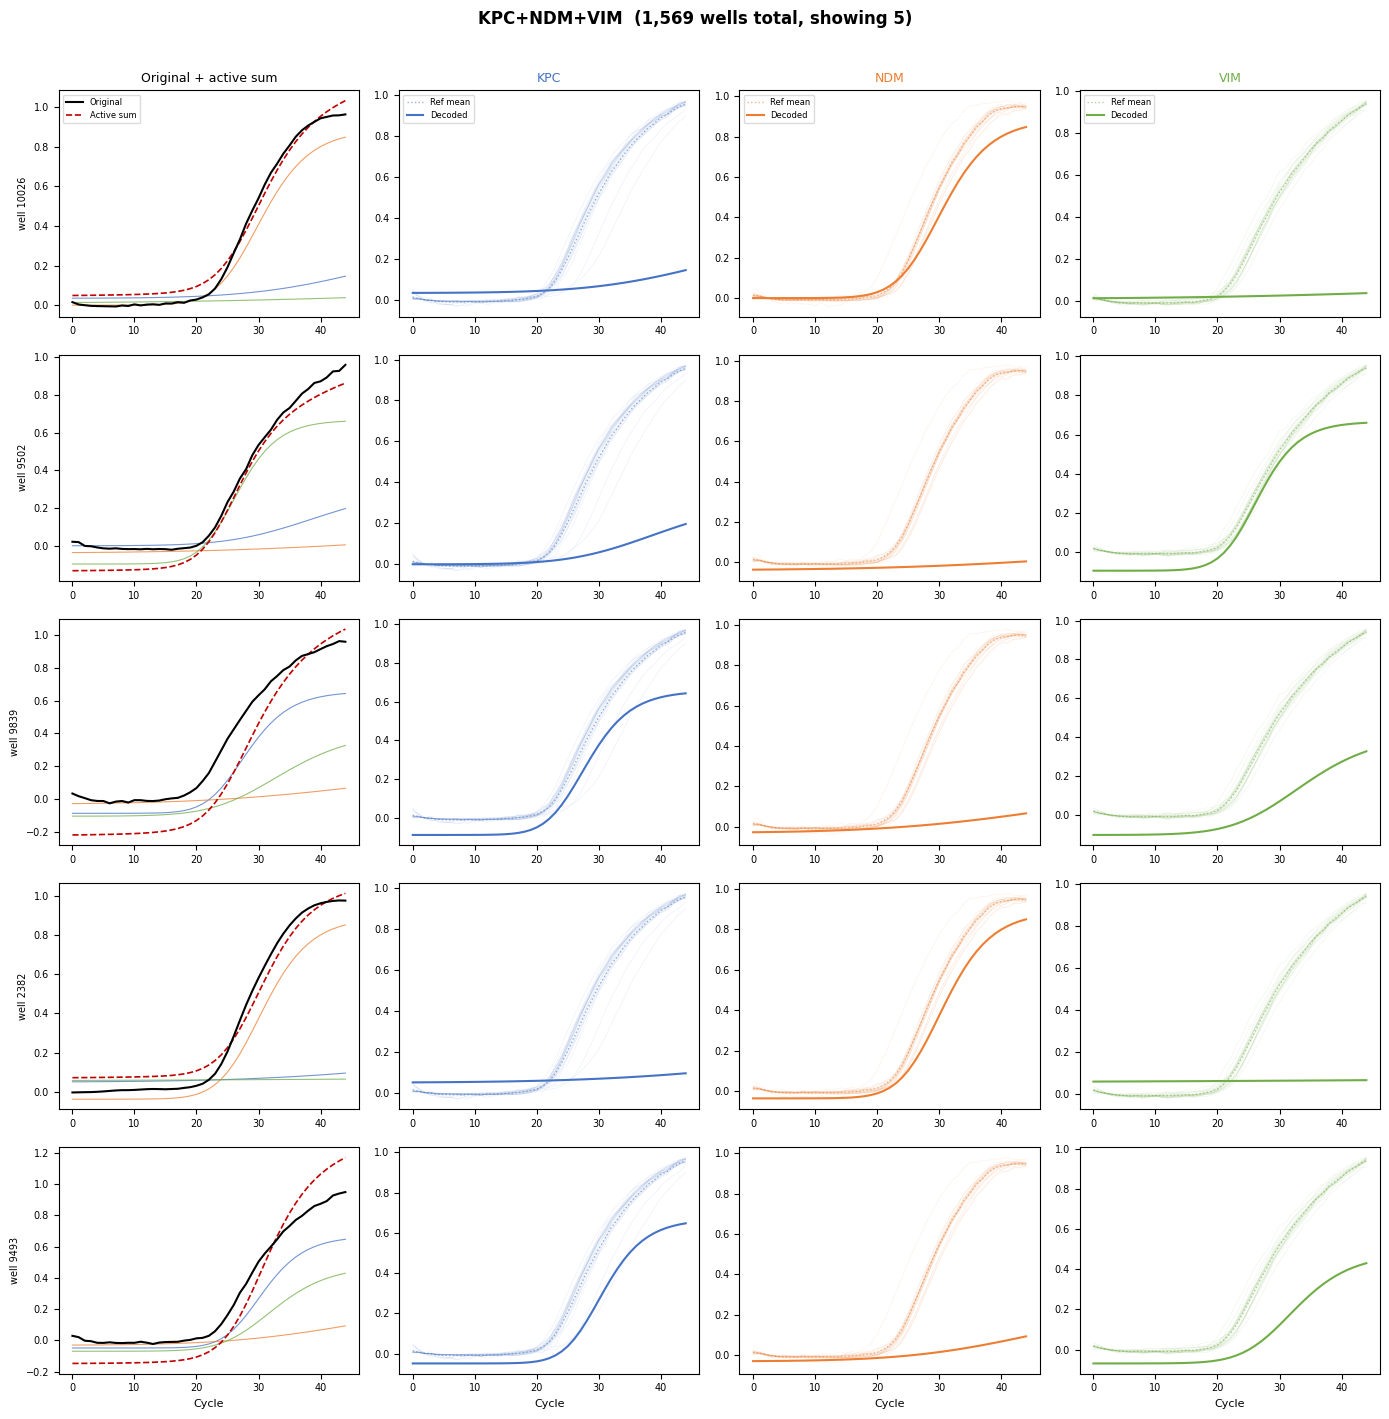

In [85]:
plot_combo([1, 1, 1])